In [88]:
import pandas as pd
import numpy as np

In [89]:
data = pd.read_excel("BDA_sheet.xlsx")
data.head(5)

,Transaction ID,Customer ID,category,Item,Price Per Unit,Quantity,Total Spent,Discount given,Payment Method,Transaction Id,Card type,Location,Pincode,Date
0,TXN_6867343,CUST_09,Home,Item_01,5.0,1.0,-2.0,7.0,Cash,NaN,NaN,Bangur Nagar,400090.0,NaN
1,TXN_7482416,CUST_09,Grocery,Item_10_PAT,18.5,8.0,136.0,12.0,Credit Card,738196052.0,Visa,Kurl,400070.0,2024-04-08 00:00:00
2,TXN_4413070,CUST_14,Home,Item_01,5.0,8.0,31.0,9.0,Credit Card,746724054.0,Visa,Parel,400012.0,11/31/2023
3,TXN_7563311,CUST_23,Grocery,Item_10_PAT,18.5,2.0,27.0,10.0,Google Pay,532940866.0,NaN,Kurla,400070.0,2022-05-20 00:00:00
4,TXN_7138501,CUST_18,Home,Item_01,5.0,1.0,-10.0,15.0,Credit Card,628129987.0,Visa,Sewree,400015.0,2024-11-16 00:00:00


In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction ID   3068 non-null   object 
 1   Customer ID      3068 non-null   object 
 2   category         3068 non-null   object 
 3   Item             2841 non-null   object 
 4   Price Per Unit   2948 non-null   float64
 5   Quantity         3068 non-null   float64
 6   Total Spent      3068 non-null   float64
 7   Discount given   3068 non-null   float64
 8   Payment Method   3068 non-null   object 
 9   Transaction Id   1633 non-null   float64
 10  Card type        1044 non-null   object 
 11  Location         3068 non-null   object 
 12  Pincode          3068 non-null   float64
 13  Date             3068 non-null   object 
dtypes: float64(6), object(8)
memory usage: 335.8+ KB


In [91]:
# now remove the 2nd transaction id column
data.drop(data.columns[9], axis=1, inplace=True)
data.head(5)

,Transaction ID,Customer ID,category,Item,Price Per Unit,Quantity,Total Spent,Discount given,Payment Method,Card type,Location,Pincode,Date
0,TXN_6867343,CUST_09,Home,Item_01,5.0,1.0,-2.0,7.0,Cash,NaN,Bangur Nagar,400090.0,NaN
1,TXN_7482416,CUST_09,Grocery,Item_10_PAT,18.5,8.0,136.0,12.0,Credit Card,Visa,Kurl,400070.0,2024-04-08 00:00:00
2,TXN_4413070,CUST_14,Home,Item_01,5.0,8.0,31.0,9.0,Credit Card,Visa,Parel,400012.0,11/31/2023
3,TXN_7563311,CUST_23,Grocery,Item_10_PAT,18.5,2.0,27.0,10.0,Google Pay,NaN,Kurla,400070.0,2022-05-20 00:00:00
4,TXN_7138501,CUST_18,Home,Item_01,5.0,1.0,-10.0,15.0,Credit Card,Visa,Sewree,400015.0,2024-11-16 00:00:00


In [92]:
data.isnull().sum()

,0
Transaction ID,1
Customer ID,1
category,1
Item,228
Price Per Unit,121
Quantity,1
Total Spent,1
Discount given,1
Payment Method,1
Card type,2025


In [93]:
#remove the null transaction id as it's only one

data = data[data["Transaction ID"].notna()]
data.isnull().sum()

,0
Transaction ID,0
Customer ID,0
category,0
Item,227
Price Per Unit,120
Quantity,0
Total Spent,0
Discount given,0
Payment Method,0
Card type,2024


In [94]:
print("Item unique values ",data["Item"].unique())

data["Item"] = data["Item"].str.lower()
data["Item"] = data["Item"].str.replace(r"[.,]", "", regex=True)
data["Item"] = data["Item"].str.replace("_pat", "", regex=False)
data["Item"] = data["Item"].str.extract(r"(\d+)")
data["Item"] = "Item_" + data["Item"].str.zfill(2)

print("Item unique values after processing",data["Item"].unique())

Item unique values  ['Item_01' 'Item_10_PAT' 'Item_17_PAT' 'it,06' 'it,07' 'it,08'
 'Item_25_PAT' 'Item_4_PAT' 'Item_12_PAT' 'Item_6_PAT' 'Item_16_PAT'
 'Item_02' 'Item_7_PAT' 'Item_15_PAT' 'Item_24_PAT' nan 'Item_20_PAT'
 'Item_9_PAT' 'Item_8_PAT' 'Item_11_PAT' 'Item_14_PAT' 'Item_2_PAT'
 'Item_13_PAT' 'Item_22_PAT' 'Item_1_PAT' 'item_03' 'Item_23_PAT'
 'Item_19_PAT' 'item_04' 'Item_5_PAT' 'Item_3_PAT' 'item_05' 'ite,m_01'
 'Item_21_PAT' 'Item.03' 'ite,m.05' 'item_01' 'it01' 'it03' 'it04' 'it02'
 'Item_18_PAT' 'item01' 'item_02' 'it,o3' 'it_oo5' 'item02' 'it,m_02'
 'ite,05' 'ite,03' 'item,01' 'i01' 'io2' 'io1' 'io4' 'io5' 'itm_17'
 'item,o4' 'ite,m02' 'item04' 'item,m01' 'ie03' 'ie05' 'itm,03' 'item_1'
 'itm_02' 'ite,m01' 'item,m02']
Item unique values after processing ['Item_01' 'Item_10' 'Item_17' 'Item_06' 'Item_07' 'Item_08' 'Item_25'
 'Item_04' 'Item_12' 'Item_16' 'Item_02' 'Item_15' 'Item_24' nan 'Item_20'
 'Item_09' 'Item_11' 'Item_14' 'Item_13' 'Item_22' 'Item_03' 'Item_23'
 '

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

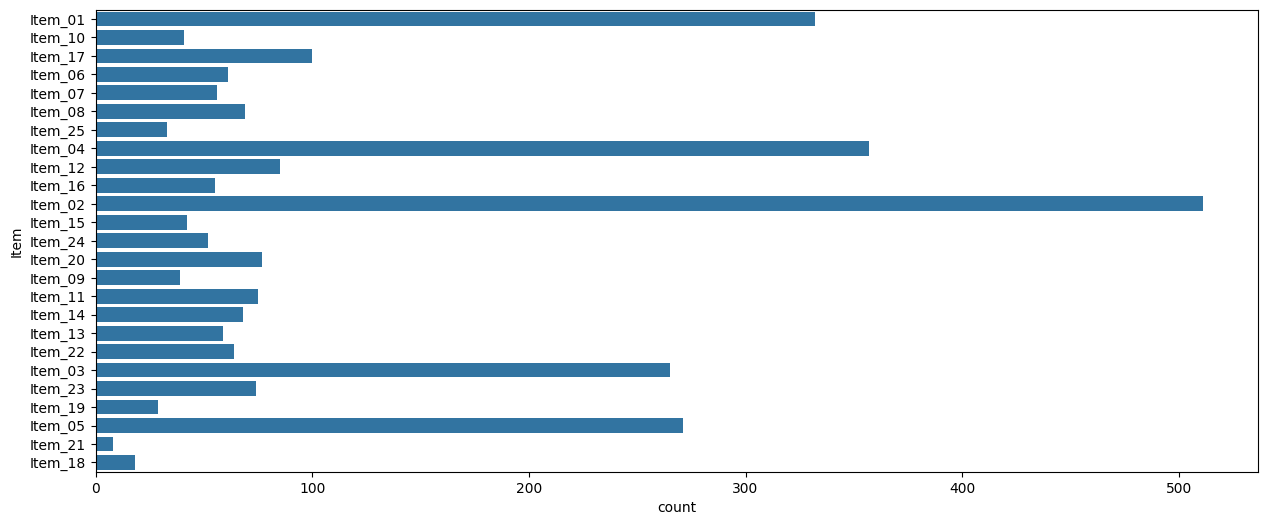

In [96]:
plt.figure(figsize=(15,6))
sns.countplot(data["Item"])
plt.show()

In [97]:
data["Item"] = data["Item"].fillna(data["Item"].mode()[0])
data["Item"].isnull().sum()

np.int64(0)

<Axes: xlabel='Price Per Unit', ylabel='Count'>

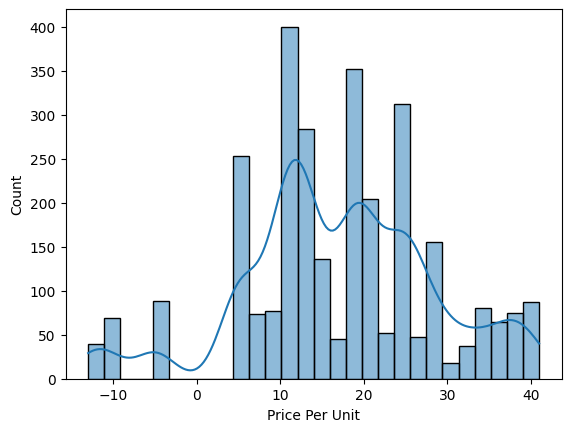

In [98]:
sns.histplot(data["Price Per Unit"],kde=True)

In [99]:
print(data["Price Per Unit"].mean())
data["Price Per Unit"] = data["Price Per Unit"].fillna(data["Price Per Unit"].mean())
data["Price Per Unit"].isnull().sum()

17.046811397557665


np.int64(0)

In [100]:
data["Card type"].unique()

array([nan, 'Visa', 'Master card', 'Fuel', 'American Express', 'Vis',
       'Mastero', 'A Exp', 'America', 'Discover', 'Viza', 'neon', 'VISA',
       'MaTERO', 'Amareica'], dtype=object)

In [101]:
data["Card type"] = data['Card type'].replace(["VISA","Vis","Viza"],"Visa")
data["Card type"] = data['Card type'].replace("A Exp","American Express")
data["Card type"] = data['Card type'].replace(["Mastero","MaTERO"],"Metro")
data["Card type"] = data['Card type'].replace("Amareica","America")

mode_value = data["Card type"].mode()[0]
print(mode_value)

data["Card type"] = data["Card type"].replace("neon",mode_value)

data["Card type"].unique()

American Express


array([nan, 'Visa', 'Master card', 'Fuel', 'American Express', 'Metro',
       'America', 'Discover'], dtype=object)

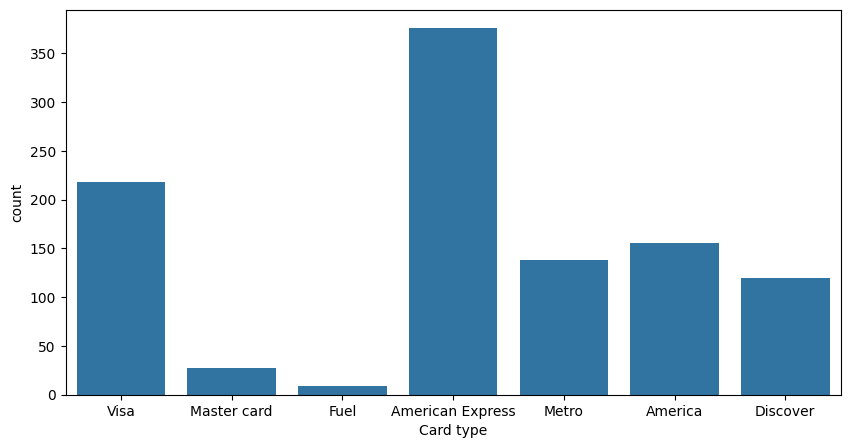

In [102]:
plt.figure(figsize=(10,5))
sns.countplot(x='Card type', data=data)
plt.show()


In [103]:
print(data["Card type"].mode()[0])
data["Card type"] = data["Card type"].fillna(data["Card type"].mode()[0])
data["Card type"].isnull().sum()

American Express


np.int64(0)

In [104]:
data["Location"].unique()

array(['Bangur Nagar', 'Kurl', 'Parel', 'Kurla', 'Sewree', 'Antop Hill',
       'Grantt Road', 'Nehru Nagar', 'Malad', 'Dharavi', 'Zumbala Hill',
       'Trombay', 'Kalbadevi', 'Antope', 'Grat Road', 'Malbar Hill',
       'Mumbai Central', 'Bangurr', 'Mandvi', 'Antop ', 'Siwree',
       'Kalba devi', 'Manad', 'Mandvir', 'Cumbala Hills', 'Parle',
       'Malda', 'N Nagar', 'Cum Hills', 'Tilak', 'antipe Hill',
       'Bang Nagar', 'Sewri', 'Gratt Road', 'Ant Hill', 'Cumba Hills',
       'Paral', 'Mandiv', 'karla', 'Bangur Nagr', 'hutam hills',
       'ala Hills', 'Jogeshwari', 'Kaldadevi', 'ant hil;', 'Bagur Nagar',
       'kurle', 'Bangur Naar', 'perul', 'ant Hills', 'Mandivs',
       'gat road', 'Bangr Nagar', 'any hill', 'Sewre', 'Sion', 'bandra',
       'Ghatkopar', 'Nenru Nagar', 'Kurda', 'Parul', 'sewri', 'Gat',
       'Kalda devi', 'Colaba', 'Powai', 'colar', 'Puwai', 'Tilak Nagar',
       'Tilak Nagare', 'mandvi', 'seepz', 'Pouai', 'NITIE', 'mandir',
       'Nehru Nagare', 'gran 

In [105]:
!pip install rapidfuzz

In [106]:
correct_locations = [
    "Kurla","Grant Road","Sewree","Malabar Hill","Bangur Nagar","Mandvi",
    "Kalbadevi","Powai","Nehru Nagar","Ghatkopar","Andheri","Jogeshwari",
    "Aarey Colony","Tilak Nagar","Hutatma Chowk","Bandra","Colaba",
    "Parel","Malad","Sion","Dharavi","Santacruz","Mulund","Mazgaon"
]

from rapidfuzz import process

def correct_location(name):
    match, score, _ = process.extractOne(name, correct_locations)
    return match if score > 70 else name   # threshold

data["Location"] = data["Location"].apply(correct_location)

data["Location"].unique()


array(['Bangur Nagar', 'Kurla', 'Parel', 'Sewree', 'Antop Hill',
       'Grant Road', 'Nehru Nagar', 'Malad', 'Dharavi', 'Zumbala Hill',
       'Trombay', 'Kalbadevi', 'Antope', 'Malabar Hill', 'Mumbai Central',
       'Mandvi', 'Antop ', 'Cumbala Hills', 'Cum Hills', 'Tilak Nagar',
       'antipe Hill', 'Cumba Hills', 'karla', 'hutam hills', 'Jogeshwari',
       'ant hil;', 'kurle', 'perul', 'ant Hills', 'gat road', 'any hill',
       'Sion', 'Bandra', 'Ghatkopar', 'sewri', 'Gat', 'Colaba', 'Powai',
       'colar', 'seepz', 'NITIE', 'mandir', 'Andheri', 'nite', 'nahur',
       'Hutatma Chowk', 'zeepz', 'Seepz', 'Mandar', 'Santacruz',
       'Mazgaon', 'colala', 'Aarey Colony', 'Aarey Milk', 'Anand Parbat',
       'seep', 'coala', 'kuda', ' Milk colony', 'Mulund', 'powau',
       'zantel', 'tromb', 'naintal', 'nitie', 'poawi'], dtype=object)

In [107]:
data.isnull().sum()
data["Pincode"] = data["Pincode"].astype(int)
data["Pincode"].unique()

#there are many correct pincode but there are many wrong pincode with the wrong leng

array([ 400090,  400070,  400012,  400015,  410037,  400007,  400024,
        400097,  400017,  400026,  400073,  400002,  400064,  400006,
        400008,  403070,  401097,  400003,  400035, 4010064, 4000614,
        400126,  400095, 4000208, 4000276, 4001006,  420070,  400014,
        410002, 4000947,  410064,  400197, 4000006,  400190,  410045,
        410097, 4001090, 4000604,  401015, 4001015, 4000105,  410026,
        403073,  410070,  400028,  400373,   40064,  400270, 4000150,
             1,  400018, 4006064,  430070,  410008, 4000190, 4100064,
       4080015,  408015, 4010090, 4001064,  400034,  400102,  480015,
        400076,  420015, 4000674,  400005,  401002,  400036,  400075,
        400089,  402022,  402036,  400025,  400037,  400069,  400890,
       4020202,  401008,  400087,  403069,  400020,  410036,  400091,
        400043,  405043,  400033,  402069,  400065,  400465, 4020022,
        402097,  400023,  400077,  440043,  400062,  401077,  400049,
        401036,  110

In [108]:
print(data[["Location","Pincode"]])

data["Pincode"] = data["Pincode"].astype(str)
data.loc[data["Pincode"].str.len() != 6, "Pincode"] = None

data["Pincode"] = data.groupby("Location")["Pincode"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)
)

mode_pin = data["Pincode"].mode()[0]
data["Pincode"] = data["Pincode"].fillna(mode_pin)

data["Pincode"].str.len().value_counts()


          Location  Pincode
0     Bangur Nagar   400090
1            Kurla   400070
2            Parel   400012
3            Kurla   400070
4           Sewree   400015
...            ...      ...
3063     Santacruz   400043
3064       Andheri   400069
3065         NITIE   400087
3066    Grant Road   400033
3067       Andheri   400069

[3068 rows x 2 columns]


,count
Pincode,
6,3068


In [109]:
data.isnull().sum()

,0
Transaction ID,0
Customer ID,0
category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Discount given,0
Payment Method,0
Card type,0


In [110]:
data["Date"]

,Date
0,NaN
1,2024-04-08 00:00:00
2,11/31/2023
3,2022-05-20 00:00:00
4,2024-11-16 00:00:00
...,...
3063,2024-05-13 00:00:00
3064,2022-08-18 00:00:00
3065,2024-08-20 00:00:00
3066,2024-11-28 00:00:00


In [111]:
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
print(data["Date"])
print(data["Date"].isnull().sum())

data["Date"] = data["Date"].fillna(data["Date"].mode()[0])
print("After filling the na values ",data["Date"].isnull().sum())

0             NaT
1      2024-04-08
2             NaT
3      2022-05-20
4      2024-11-16
          ...    
3063   2024-05-13
3064   2022-08-18
3065   2024-08-20
3066   2024-11-28
3067   2024-05-01
Name: Date, Length: 3068, dtype: datetime64[ns]
13
After filling the na values  0


(3068, 13)

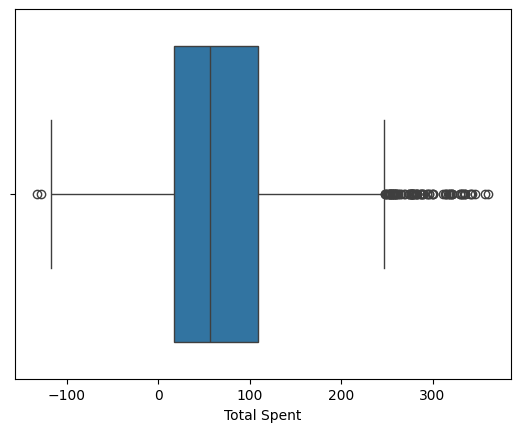

In [112]:
sns.boxplot(data=data,x="Total Spent")
data.shape

<Axes: xlabel='Total Spent'>

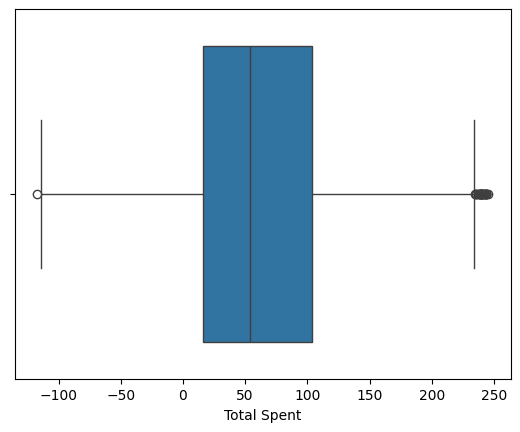

In [113]:
Q1 = data["Total Spent"].quantile(0.25)
Q3 = data["Total Spent"].quantile(0.75)
IQR = Q3 - Q1

left_side_outliers = Q1 - 1.5 * IQR
right_side_outliers = Q3 + 1.5 * IQR

data = data[(data["Total Spent"] > left_side_outliers) & (data["Total Spent"] < right_side_outliers)]
sns.boxplot(data=data,x="Total Spent")

In [114]:
data.shape

(2978, 13)

In [115]:
data.loc[data["Total Spent"] < 0 , "Total Spent"] = np.nan
data["Total Spent"].isnull().sum()

np.int64(383)

<Axes: xlabel='Total Spent', ylabel='Count'>

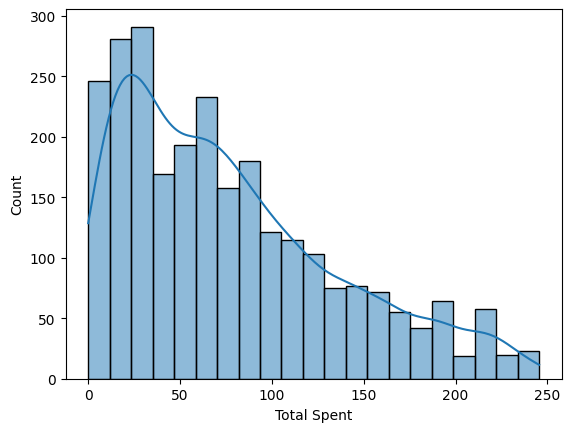

In [116]:
sns.histplot(data["Total Spent"],kde=True)

<Axes: xlabel='Total Spent'>

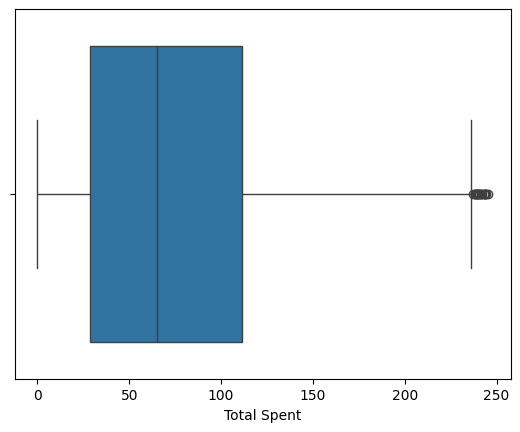

In [117]:
sns.boxplot(data=data,x="Total Spent")
#as we have normaly data right skewed removing outliers will not affect that much for normal distribution

In [118]:
data["Total Spent"] = data["Total Spent"].fillna(data["Total Spent"].median())

In [119]:
data[data["Price Per Unit"] < 0 ].count()

,0
Transaction ID,195
Customer ID,195
category,195
Item,195
Price Per Unit,195
Quantity,195
Total Spent,195
Discount given,195
Payment Method,195
Card type,195


In [120]:
print(data["Price Per Unit"].unique())

data.loc[data["Price Per Unit"] < 0, "Price Per Unit"] = np.nan

data["Price Per Unit"] = data["Price Per Unit"].fillna(data["Price Per Unit"].median())

data["Price Per Unit"].unique()

print(data.groupby("Item")["Price Per Unit"].unique())

data["Price Per Unit"] = data.groupby("Item")["Price Per Unit"].transform(
    lambda x: x.mode()[0]
)

print(data.groupby("Item")["Price Per Unit"].unique())

[  5.         18.5        29.         23.         15.5         9.5
  21.5        12.5        20.         27.5        11.         14.
  26.         39.5        33.5        17.         41.         24.5
   6.5        36.5        13.         38.         19.         32.
  17.0468114   8.         25.         35.         -5.         30.5
 -13.         21.        -11.         13.5        25.5      ]
Item
Item_01                                          [5.0, 18.5]
Item_02    [11.0, 20.0, 6.5, 9.5, 15.5, 5.0, 21.5, 17.046...
Item_03                              [13.0, 8.0, 18.5, 13.5]
Item_04                                          [9.5, 19.0]
Item_05                             [11.0, 25.0, 21.0, 25.5]
Item_06                                         [23.0, 12.5]
Item_07                                   [29.0, 20.0, 14.0]
Item_08                           [15.5, 17.046811397557665]
Item_09                                               [17.0]
Item_10                                            

In [121]:
print(data["Payment Method"].unique())

data["Payment Method"] = data["Payment Method"].replace(["Gpay","Google","Google "],"Google Pay")
data["Payment Method"] = data["Payment Method"].replace(["Ptm","Patm"],"Paytm")
data["Payment Method"] = data["Payment Method"].replace(["Bhima","Bheema "],"Bhim Pay")
data["Payment Method"] = data["Payment Method"].replace(["Amzon"],"Amazon Pay")
data["Payment Method"] = data["Payment Method"].replace(["Rupay","Rpay"],"Rupee pay")
data["Payment Method"] = data["Payment Method"].replace(["epay"],"Epay")

print(data["Payment Method"].unique())

['Cash' 'Credit Card' 'Google Pay' 'Gpay' 'Rupay' 'Bhim Pay' 'Ptm' 'Bhima'
 'Amazon Pay' 'Amzon' 'Rpay' 'epay' 'Google ' 'Paytm' 'Patm' 'Epay'
 'Google' 'Rupee pay' 'Bheema ']
['Cash' 'Credit Card' 'Google Pay' 'Rupee pay' 'Bhim Pay' 'Paytm'
 'Amazon Pay' 'Epay']


In [122]:
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["MonthDate"] = data["Date"].dt.date


In [123]:
data.head(10)

,Transaction ID,Customer ID,category,Item,Price Per Unit,Quantity,Total Spent,Discount given,Payment Method,Card type,Location,Pincode,Date,Year,Month,MonthDate
0,TXN_6867343,CUST_09,Home,Item_01,5.0,1.0,65.0,7.0,Cash,American Express,Bangur Nagar,400090,2022-08-13,2022,8,2022-08-13
1,TXN_7482416,CUST_09,Grocery,Item_10,18.5,8.0,136.0,12.0,Credit Card,Visa,Kurla,400070,2024-04-08,2024,4,2024-04-08
2,TXN_4413070,CUST_14,Home,Item_01,5.0,8.0,31.0,9.0,Credit Card,Visa,Parel,400012,2022-08-13,2022,8,2022-08-13
3,TXN_7563311,CUST_23,Grocery,Item_10,18.5,2.0,27.0,10.0,Google Pay,American Express,Kurla,400070,2022-05-20,2022,5,2022-05-20
4,TXN_7138501,CUST_18,Home,Item_01,5.0,1.0,65.0,15.0,Credit Card,Visa,Sewree,400015,2024-11-16,2024,11,2024-11-16
5,TXN_4353295,CUST_22,Home,Item_01,5.0,4.0,8.0,12.0,Google Pay,American Express,Antop Hill,410037,2022-03-10,2022,3,2022-03-10
6,TXN_1621497,CUST_06,Grocery,Item_17,29.0,7.0,192.0,11.0,Credit Card,Visa,Grant Road,400007,2022-04-05,2022,4,2022-04-05
7,TXN_9331642,CUST_12,Home,Item_01,5.0,6.0,17.0,13.0,Cash,American Express,Nehru Nagar,400024,2023-02-18,2023,2,2023-02-18
8,TXN_1132097,CUST_24,Home,Item_01,5.0,7.0,29.0,6.0,Credit Card,Visa,Malad,400097,2022-07-06,2022,7,2022-07-06
9,TXN_5885894,CUST_01,Grocery,Item_06,12.5,1.0,11.0,12.0,Cash,American Express,Kurla,400070,2023-05-18,2023,5,2023-05-18


In [124]:
data.to_excel("cleaned_data.xlsx", index=False)